In [2]:
import pandas as pd #loading data set
import numpy as np # mathematical calculation
import re # Regular Expression used for cleaning the data
import nltk # for basics
import matplotlib.pyplot as plt # visualization
from nltk.corpus import stopwords # to remove be verbs unwanted words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

In [3]:
# library for punctuation for sentiemnet
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tharu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tharu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Tharu\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Tharu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)


In [5]:
print("Customer Reviews Dataset")
print(df.head())

Customer Reviews Dataset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

  text=text.lower()
  print('lower case',text)
  # remove special charater and number
  text = re.sub(r'[^a-zA-Z\s]','',text)
  print('special character',text)
  #Tokenization
  words = word_tokenize(text)
  print('tokenization')
  # reomve stopwords
  words = [word for word in words if word not in stop_words]
  print('stopwords',words)
  # join words again
  cleaned_text =" ".join(words)

  return cleaned_text

In [7]:
# apply cleaning function
df['cleaned review'] = df['Review'].apply(clean_text)
print("\nCleaned Review")
print(df[['Review','cleaned review']])

lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
special character very bad packaging and the item was damaged
tokenization
stopwords ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
special character customer service was helpful and responsive
tokenization
stopwords ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
special character the delivery was delayed and support team did not respond
tokenization
stopwords ['delivery', 'delayed', 'support', 'team', 'respond']
lower case amazing product. worth the money.
special character amazing product worth the money
tokenization
stopwords ['amazing', 'product', 'worth', 'money']
lower case poor qu

In [8]:
print(clean_text(df['Review'].iloc[0]))

lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
product quality excellent delivery fast


In [9]:
# sentiment analysis

sia = SentimentIntensityAnalyzer()
def analyzer_sentiment(review):
  score = sia.polarity_scores(review)
  compound = score['compound']
  if compound >= 0.05:
    return "positive"

  elif compound <= -0.05:
    return "negative"
  else:
    return "neutral"

#apply sentiment analysis
df['Sentiment'] = df['cleaned review'].apply(analyzer_sentiment)
print("\nSentiment Analysis")
print(df[['Review','Sentiment']])


Sentiment Analysis
                                              Review Sentiment
0  The product quality is excellent and delivery ...  positive
1       Very bad packaging and the item was damaged.  negative
2       Customer service was helpful and responsive.  positive
3  The delivery was delayed and support team did ...  positive
4                  Amazing product. Worth the money.  positive
5      Poor quality product and terrible experience.  negative
6                  Fast shipping and good packaging.  positive
7        The product stopped working after two days.  negative
8               Excellent service and great quality.  positive
9            Late delivery and bad customer support.  negative


In [10]:
all_words=" ".join(df['cleaned review'])
word_list = all_words.split()

#count word frequency

word_freq= Counter(word_list)

#display top 10 keywords
print("\nTop  10 Common Keywords")
print(word_freq.most_common(10))



Top  10 Common Keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [11]:
# identify common complaints
negative_reviews = df[df['Sentiment'] == 'negative'] # Corrected: 'Negative' to 'negative'
negative_words_combined = " ".join(negative_reviews['cleaned review']) # Combine all cleaned negative reviews
negative_word_list = negative_words_combined.split() # Split the combined string into a list of words

# Count word frequency
word_freq_negative = Counter(negative_word_list) # Corrected: 'counter' to 'Counter'

print("\n top 10 negative keywords")
print(word_freq_negative.most_common(10))


 top 10 negative keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


In [12]:
sentiment_counts = df['Sentiment'].value_counts()
sentiment_counts

Sentiment
positive    6
negative    4
Name: count, dtype: int64

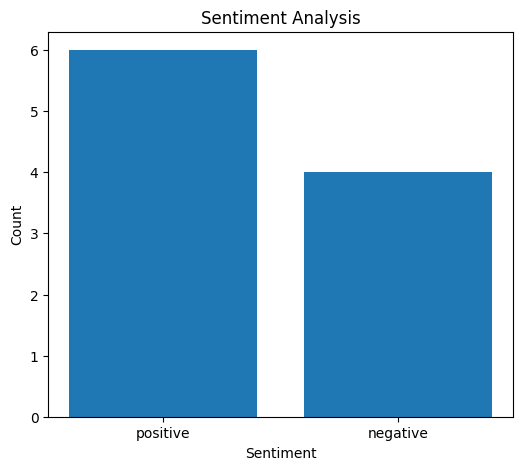

In [13]:
sentiment_counts = df["Sentiment"].value_counts()
plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Analysis")
plt.show()

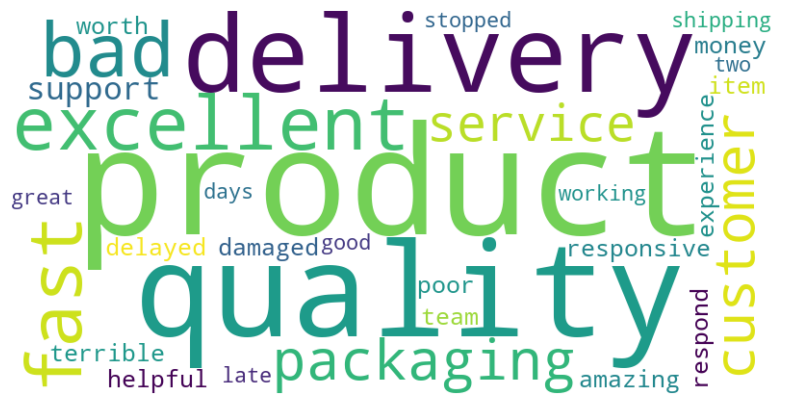

In [14]:
wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color ='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()